In [ ]:
# Loading the necessary libraries
import os
import random
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
#from google.colab import files
from IPython.display import display
from skimage import io
from skimage import filters
from skimage.feature import corner_peaks
from skimage.io import imread
from scipy.ndimage import convolve
from scipy.signal import savgol_filter

import pandas as pd
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import confusion_matrix
from skimage import feature
from imutils import build_montages
from imutils import paths
#import tensorflow as tf
from PIL import Image

In [2]:
training_path = 'C://Winter_2025/ENEL_503/Final_Project/data/spiral/training'
testing_path = 'C://Winter_2025/ENEL_503/Final_Project/data/spiral/testing'

aug_training_path = 'C://Winter_2025/ENEL_503/Final_Project/data/spiral/aug_training'
aug_testing_path = 'C://Winter_2025/ENEL_503/Final_Project/data/spiral/aug_testing'


# Set parameters
input_dir = training_path          
output_dir = aug_training_path    
num_augmentations = 5                    # Number of augmented versions per image
image_size = (256, 256)

# Create output folder
os.makedirs(output_dir, exist_ok=True)

# Load dataset with labels inferred from folder names
dataset = tf.keras.utils.image_dataset_from_directory(
        input_dir,
        image_size=image_size,
        batch_size=1,
        shuffle=False
    )

class_names = dataset.class_names  # Get class names for label mapping

# Normalize images
dataset = dataset.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))

# Define augmentation pipeline
data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip('horizontal_and_vertical') 
    ])


# Augment and save
img_count = 0

for image_batch, label_batch in dataset:
    image = image_batch[0]
    label = label_batch[0].numpy()
    class_name = class_names[label]

    for i in range(num_augmentations):
        augmented = data_augmentation(tf.expand_dims(image, axis=0), training=True)
        augmented_np = (augmented.numpy()[0] * 255).astype(np.uint8)

            # Save as PNG or JPEG
        img_pil = Image.fromarray(augmented_np)
        filename = f"{class_name}_img{img_count}_aug{i}.png"
        img_pil.save(os.path.join(output_dir, filename))

    img_count += 1

Found 72 files belonging to 2 classes.


In [3]:
# Set parameters
input_dir = testing_path          
output_dir = aug_testing_path    
num_augmentations = 5                    # Number of augmented versions per image
image_size = (256, 256)

# Create output folder
os.makedirs(output_dir, exist_ok=True)

# Load dataset with labels inferred from folder names
dataset = tf.keras.utils.image_dataset_from_directory(
    input_dir,
    image_size=image_size,
    batch_size=1,
    shuffle=False
    )

class_names = dataset.class_names  # Get class names for label mapping

# Normalize images
dataset = dataset.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))

# Define augmentation pipeline
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical') 
    ])

# Augment and save
img_count = 0

for image_batch, label_batch in dataset:
    image = image_batch[0]
    label = label_batch[0].numpy()
    class_name = class_names[label]

    for i in range(num_augmentations):
        augmented = data_augmentation(tf.expand_dims(image, axis=0), training=True)
        augmented_np = (augmented.numpy()[0] * 255).astype(np.uint8)

            # Save as PNG or JPEG
        img_pil = Image.fromarray(augmented_np)
        filename = f"{class_name}_img{img_count}_aug{i}.png"
        img_pil.save(os.path.join(output_dir, filename))

    img_count += 1

Found 30 files belonging to 2 classes.


Loaded 360 training images:
  - Healthy: 180
  - Parkinson's: 180 

Loaded 150 testing images:
  - Healthy: 75
  - Parkinson's: 75 

Displaying image: healthy_img27_aug2.png
Label: Healthy


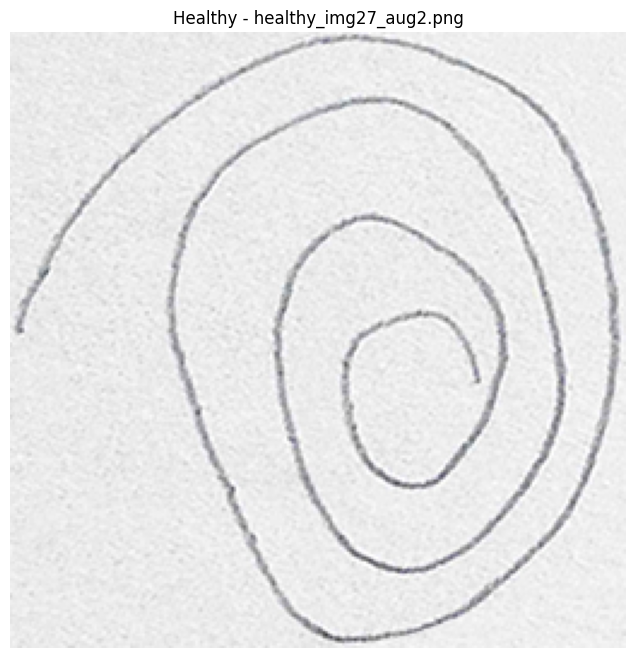

In [2]:
healthy_training_dir = 'C://Winter_2025/ENEL_503/Final_Project/data/spiral/aug_training/healthy'
parkinson_training_dir = 'C://Winter_2025/ENEL_503//Final_Project/data/spiral/aug_training/parkinson'

healthy_testing_dir = 'C://Winter_2025/ENEL_503/Final_Project/data/spiral/aug_testing/healthy'
parkinson_testing_dir = 'C://Winter_2025/ENEL_503//Final_Project/data/spiral/aug_testing/parkinson'

# Function to load images and their labels
def load_images(healthy_path, parkinson_path):
    images = []
    labels = []
    filenames = []

    # Load healthy images (label 0)
    for filename in os.listdir(healthy_path):
        img_path = os.path.join(healthy_path, filename)
        img = cv.imread(img_path)

        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Convert to RGB
            images.append(img)
            labels.append(0)  # 0 for healthy
            filenames.append(img_path)

    # Load Parkinson's images (label 1)
    for filename in os.listdir(parkinson_path):
        img_path = os.path.join(parkinson_path, filename)
        img = cv.imread(img_path)

        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Convert to RGB
            images.append(img)
            labels.append(1)  # 1 for Parkinson's
            filenames.append(img_path)

    return images, labels, filenames

# Display a random image from the dataset
def display_random_image(images, labels, filenames):
    if not images:
        print("No images found")
        return

    idx = random.randrange(len(images))
    image = images[idx]
    label = "Healthy" if labels[idx] == 0 else "Parkinson's"
    filename = os.path.basename(filenames[idx])

    print(f"Displaying image: {filename}")
    print(f"Label: {label}")

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.title(f"{label} - {filename}")
    plt.axis('off')
    plt.show()

    return image, labels[idx], filenames[idx]

# Load all images and their labels
try:
    # Loading training images
    all_training_images, all_training_labels, all_training_filenames = load_images(healthy_training_dir, parkinson_training_dir)
    print(f"Loaded {len(all_training_images)} training images:")
    print(f"  - Healthy: {all_training_labels.count(0)}")
    print(f"  - Parkinson's: {all_training_labels.count(1)} \n")

    # Loading testing images
    all_testing_images, all_testing_labels, all_testing_filenames = load_images(healthy_testing_dir, parkinson_testing_dir)
    print(f"Loaded {len(all_testing_images)} testing images:")
    print(f"  - Healthy: {all_testing_labels.count(0)}")
    print(f"  - Parkinson's: {all_testing_labels.count(1)} \n")


    # Display a random image
    random_image, label, image_path = display_random_image(all_training_images, all_training_labels, all_training_filenames)

except FileNotFoundError as e:
    print(f"Directory not found: {e}")
    print("Please check if the paths are correct or upload your files first")



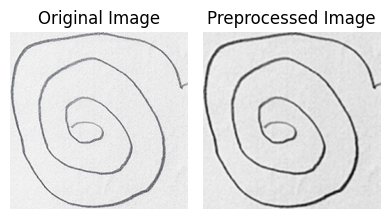

Label: Parkinson's


In [3]:
def preprocess_spiral_image(image):
    if len(image.shape) == 3:
        gray = cv.cvtColor(image, cv.COLOR_RGB2GRAY)
    else:
        gray = image.copy()

    blurred = cv.GaussianBlur(gray, (5, 5), 0)  # Apply Gaussian blur to reduce noise

    # Apply unsharp masking to make spiral lines more visible https://stackoverflow.com/questions/32454613/python-unsharp-mask
    gaussian_blur = cv.GaussianBlur(blurred, (0, 0), sigmaX=2)
    enhanced = cv.addWeighted(blurred, 1.5, gaussian_blur, -0.5, 0)
    return enhanced

# Function to display original and preprocessed images side by side
def show_preprocessing_result(image):
    plt.figure(figsize=(4, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(preprocess_spiral_image(image), cmap='gray')
    plt.title('Preprocessed Image')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return processed

# Process all training images
preprocessed_training_images = []
for img in all_training_images:
    preprocessed = preprocess_spiral_image(img)
    preprocessed_training_images.append(preprocessed)

# Process all testing images
preprocessed_testing_images = []
for img in all_testing_images:
    preprocessed = preprocess_spiral_image(img)
    preprocessed_testing_images.append(preprocessed)


# Show a random example from training set
i = random.randrange(len(all_training_images))
original = all_training_images[i]
processed = preprocessed_training_images[i]
if all_training_labels[i] == 0:
    label = "Healthy"
else:
    label = "Parkinson's"
filename = os.path.basename(all_training_filenames[i])

show_preprocessing_result(original)
print(f"Label: {label}")


In [4]:
def harris_corners(img, window_size=3, k=0.04):
    
    H = img.shape[0]
    W = img.shape[1]
    window = np.ones((window_size, window_size))

    response = np.zeros((H, W))

    I_x = filters.sobel_v(img)
    I_y = filters.sobel_h(img) 

    image_x = (I_x)**2
    image_y = (I_y)**2
    image_xy = (I_x)*(I_y)

    M_x = convolve(image_x, window, mode = 'constant', cval=0)
    M_y = convolve(image_y, window, mode = 'constant', cval=0)
    M_xy = convolve(image_xy, window, mode = 'constant', cval=0)

    det_M = (M_x*M_y)-(M_xy**2)

    trace_M = M_x + M_y

    response = det_M - k*(trace_M**2)

    return response

In [5]:
def tremor_index(image):
    if len(image.shape) == 3:
        gray = cv.cvtColor(image, cv.COLOR_RGB2GRAY)
    else:
        gray = image.copy()
    #image = cv.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Threshold to binary
    _, binary = cv.threshold(gray, 200, 255, cv.THRESH_BINARY_INV)

    # Find contours
    contours, _ = cv.findContours(binary, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

    # Select the longest contour (assumed to be the spiral)
    spiral_contour = max(contours, key=len)
    points = spiral_contour[:, 0, :]  # shape: (N, 2)

    # Separate x and y
    x, y = points[:, 0], points[:, 1]

    # Smooth the contour using Savitzky-Golay filter
    x_smooth = savgol_filter(x, window_length=31, polyorder=3)
    y_smooth = savgol_filter(y, window_length=31, polyorder=3)

    # Compute jitter as deviation from smoothed path
    jitter = np.sqrt((x - x_smooth)**2 + (y - y_smooth)**2)
    tremor_index = np.std(jitter)

    return tremor_index

In [6]:
# Feature Extraction
from skimage.measure import label as sk_label, regionprops
from skimage.feature import corner_peaks

def extract_features(image):
    # adapted from https://medium.com/@flippygarcia/application-of-image-processing-in-machine-learning-using-python-8267e596e071

    labeled_image = sk_label(image)
    regions = regionprops(labeled_image)

    features = {}
    if len(regions) > 0:
        # Select the largest region (assuming the outer spiral is the largest)
        largest_region = max(regions, key=lambda r: r.area)

        # Extract area and perimeter
        area = largest_region.area
        perimeter = largest_region.perimeter

        # Compute circularity
        if perimeter > 0:
                circularity = 4 * np.pi * area / (perimeter ** 2)
        else:
            circularity = 0

        # Extract eccentricity
        eccentricity = largest_region.eccentricity

        features['circularity'] = circularity
        features['eccentricity'] = eccentricity
        
    else:
        features['circularity'] = 0
        features['eccentricity'] = 0
    
    #Extract corners
    response = harris_corners(image)
    corners = corner_peaks(response, threshold_rel=0.05)

    features['corners'] = len(corners)

    #Tremor Index
    tremor_idx = tremor_index(image)

    features['tremor_index'] = tremor_idx

    return features

def visualize_features(image, features): # ai gen for validation purposes :)
    # Create a color version of the image for better visualization
    if len(image.shape) == 2:  # Grayscale image
        display_img = cv.cvtColor(image, cv.COLOR_GRAY2RGB)
    else:  # Color image
        display_img = image.copy()

    # Display the image
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(display_img)
    plt.title('Image')
    plt.axis('off')

    # Display the features as text
    plt.subplot(1, 2, 2)
    plt.axis('off')
    plt.text(0.1, 0.9, f"Circularity: {features['circularity']:.4f}", fontsize= 12)
    plt.text(0.1, 0.8, f"Eccentricity: {features['eccentricity']:.4f}", fontsize= 12)
    plt.text(0.1, 0.7, f"Corners Detected:{features['corners']:.4f}", fontsize= 12)
    plt.text(0.1, 0.6, f"Tremor Index: {features['tremor_index']:.4f}", fontsize=12)
    plt.title('Extracted Features')

    plt.tight_layout()
    plt.show()



Sample image label: Parkinson's


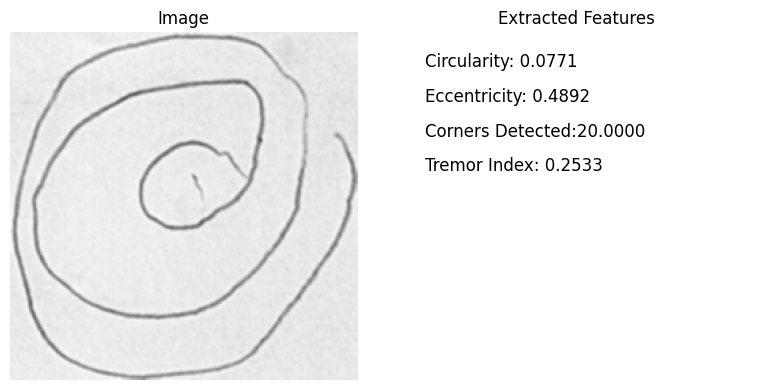

In [7]:
idx = random.randrange(len(preprocessed_training_images))
sample_image = preprocessed_training_images[idx]
sample_features_dict = extract_features(sample_image)
label = "Healthy" if all_training_labels[idx] == 0 else "Parkinson's"

print(f"Sample image label: {label}")
visualize_features(sample_image, sample_features_dict)

In [8]:
# Extracting features and storing in a dataframe - training dataset
# Initialize a list to store all features
training_features_list = []

for i, img in enumerate(preprocessed_training_images):
    features = extract_features(img)

    # Add label information
    label_name = "Healthy" if all_training_labels[i] == 0 else "Parkinson's"
    features['label_name'] = label_name

    training_features_list.append(features)

# Create DataFrame from all features
training_features_df = pd.DataFrame(training_features_list)

# Extracting features and storing in a dataframe - testing dataset
testing_features_list = []

for i, img in enumerate(preprocessed_testing_images):
    features = extract_features(img)

    # Add label information
    label_name = "Healthy" if all_testing_labels[i] == 0 else "Parkinson's"
    features['label_name'] = label_name

    testing_features_list.append(features)

# Create DataFrame from all features
testing_features_df = pd.DataFrame(testing_features_list)


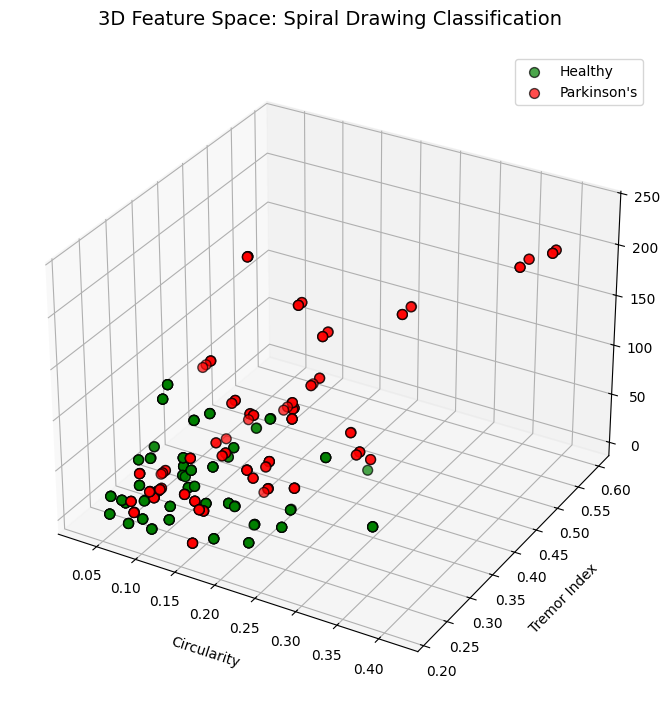

In [9]:
# Visualizing the feature space with the training set

#from mpl_toolkits.mplot3d import Axes3D
#import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

#fig = plt.figure(figsize=(10, 8))
#ax = fig.add_subplot(projection='3d')


# Extract features for each class
healthy = training_features_df[training_features_df['label_name'] == 'Healthy']
parkinsons = training_features_df[training_features_df['label_name'] == "Parkinson's"]

# Plot Healthy data
ax.scatter(
    healthy['circularity'], healthy['tremor_index'], healthy['corners'],
    c='g', marker='o', s=50, label='Healthy', alpha=0.7, edgecolors='k'
)

# Plot Parkinson's data
ax.scatter(
    parkinsons['circularity'], parkinsons['tremor_index'], parkinsons['corners'],
    c='r', marker='o', s=50, label="Parkinson's", alpha=0.7, edgecolors='k'
)

#xs = training_features_df.loc[training_features_df['label_name']=='Healthy', 'circularity']
#ys = training_features_df.loc[training_features_df['label_name']=='Healthy', 'tremor_index']
#zs = training_features_df.loc[training_features_df['label_name']=='Healthy', 'corners']

#xt = training_features_df.loc[training_features_df['label_name']=="Parkinson's", 'circularity']
#yt = training_features_df.loc[training_features_df['label_name']=="Parkinson's", 'tremor_index']
#zt = training_features_df.loc[training_features_df['label_name']=="Parkinson's", 'corners']

#ax.scatter(xs, ys, zs, c='r', marker='o')
#ax.scatter(xt, yt, zt, c='g', marker='o')


# Axis labels
ax.set_xlabel('Circularity', labelpad=10)
ax.set_ylabel('Tremor Index', labelpad=10)
ax.set_zlabel('Corners', labelpad=10)
#ax.set_zlabel('Corners', fontsize=12, labelpad=10)
#ax.zaxis.label.set_size(12)
#ax.zaxis.label.set_rotation(90)
#ax.zaxis.label.set_color('black')
#ax.zaxis.label.set_rotation(90)

# Title and legend
ax.set_title('3D Feature Space: Spiral Drawing Classification', fontsize=14, pad=20)
ax.legend(loc='upper right')

# Improve layout
#plt.tight_layout()
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
plt.show()


In [10]:
#Classification of the Feature Space
#import sklearn
#from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline

X_train = training_features_df[['circularity', 'corners', 'tremor_index']]
y_train = training_features_df['label_name']

X_test = testing_features_df[['circularity', 'corners', 'tremor_index']]
y_test = testing_features_df['label_name']

# Encode labels to 0 and 1
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [11]:
def compute_metrics(cm):
    cm = cm.flatten()
    tn, fp, fn, tp = cm
    metrics = {
        "Accuracy": (tp + tn) / float(cm.sum()),
        "Precision": tp / float(tp + fp),
        "Recall (Sensitivity)": tp / float(tp + fn),
        "Specificity": tn / float(tn + fp)
    }
    return metrics

In [13]:
from sklearn.svm import LinearSVC

[INFO] training RandomForest...
Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best hyperparameters for RandomForest: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}

RandomForest Metrics:
Accuracy: 0.7600

Precision: 0.7143

Recall (Sensitivity): 0.8667

Specificity: 0.6533



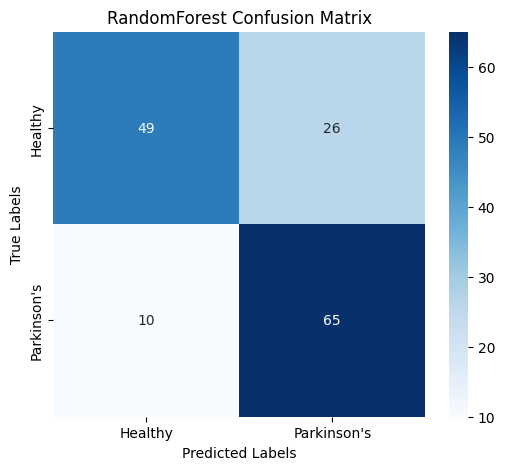

[INFO] training SVM Linear...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best hyperparameters for SVM Linear: {'C': 10}

SVM Linear Metrics:
Accuracy: 0.7133

Precision: 0.6818

Recall (Sensitivity): 0.8000

Specificity: 0.6267



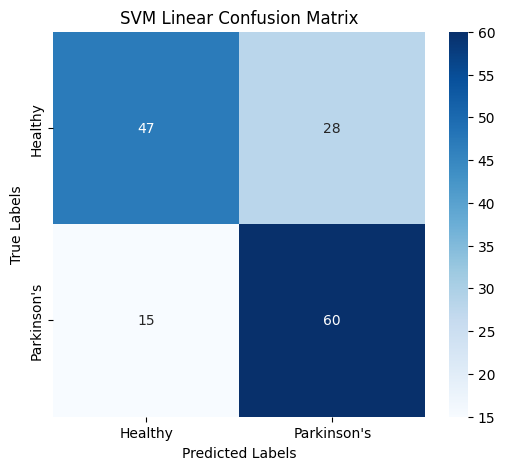

[INFO] training SVM RBF...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best hyperparameters for SVM RBF: {'C': 1, 'gamma': 'auto'}

SVM RBF Metrics:
Accuracy: 0.4333

Precision: 0.4000

Recall (Sensitivity): 0.2667

Specificity: 0.6000



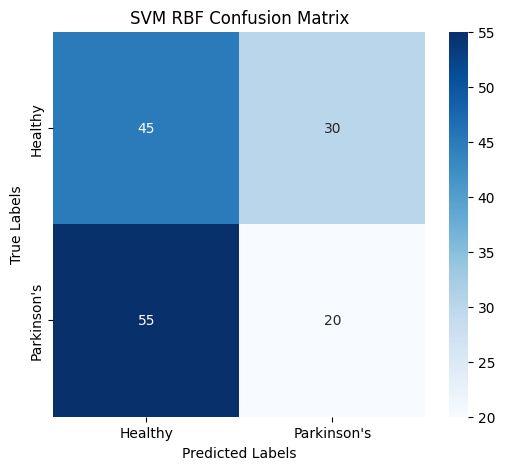

In [14]:
# Define the classifiers to use
classifiers = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "SVM Linear": LinearSVC(random_state=42),
    "SVM RBF": SVC(kernel='rbf', random_state=42)
}

# Tune hyperparameters for each classifier systematically using GridSearchCV
param_grid = {
    'RandomForest': {
        'n_estimators': [50, 100, 150],           # num of trees in forest
		'max_depth': [None, 10, 20, 30],          # max depth of tree
		'min_samples_split': [2, 5, 10],          # min num of samples required to split a node
		'min_samples_leaf': [1, 2, 4],            # min num of samples required to be at a leaf node
		'max_features': ['sqrt', 'log2', None]    # num of features to consider at each split
	},
    'SVM Linear': {
        'C': [0.1, 1, 10]   # regularization parameter
    },
    'SVM RBF': {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto']     # controls radius of influence of support vectors
    }
}

# Store the fitted models
fitted_classifiers = {}

# Train and evaluate classifiers
for clf_name, clf in classifiers.items():
    print(f"[INFO] training {clf_name}...")

    # Initialize GridSearchCV
    # Use cross-validation (cv), and give detailed output (verbose=2)
    grid_search = GridSearchCV(estimator=clf, param_grid=param_grid[clf_name], cv=3, n_jobs=-1, verbose=2)

    # Train the model
    grid_search.fit(X_train, y_train)

    # Get the best hyperparameters
    print(f"Best hyperparameters for {clf_name}: {grid_search.best_params_}")

    # Store the best fitted model found by GridSearchCV for that classifier
    fitted_classifiers[clf_name] = grid_search.best_estimator_

    # Train the best model for that classifier
    fitted_classifiers[clf_name].fit(X_train, y_train)

    # Make predictions on testing data
    predictions = fitted_classifiers[clf_name].predict(X_test)

    # Compute confusion matrix and use it to derive the raw
    # accuracy, precision, recall (sensitivity), and specificity
    cm_original = confusion_matrix(y_test, predictions)
    metrics = compute_metrics(cm_original)

    # Display the metrics 
    print(f"\n{clf_name} Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
        print("")
    
    # Display confusion matrix 
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', xticklabels=["Healthy", "Parkinson's"], yticklabels=["Healthy", "Parkinson's"])
    plt.title(f'{clf_name} Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

We were having issues with the cell below. Including the SVC with a polynomial kernel in the grid search was causing delays in processing. The cell below is included for clarity, however the final solution (with 'best parameters') is found in the cell following this one. 

In [ ]:
# Define the classifiers to use
classifiers = {
    "SVM Poly": SVC(kernel='poly', random_state=42)
}

# Tune hyperparameters for each classifier systematically using GridSearchCV
param_grid = {
    'SVM Poly': {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'degree': [2, 3]     # defines degree of the polynomial kernel
    }
}

# Store the fitted models
fitted_classifiers = {}

# Train and evaluate classifiers
for clf_name, clf in classifiers.items():
    print(f"[INFO] training {clf_name}...")

    # Initialize GridSearchCV
    # Use cross-validation (cv), and give detailed output (verbose=2)
    grid_search = GridSearchCV(estimator=clf, param_grid=param_grid[clf_name], cv=3, n_jobs=-1, verbose=2)

    # Train the model
    grid_search.fit(X_train, y_train)

    # Get the best hyperparameters
    print(f"Best hyperparameters for {clf_name}: {grid_search.best_params_}")

    # Store the best fitted model found by GridSearchCV for that classifier
    fitted_classifiers[clf_name] = grid_search.best_estimator_

    # Train the best model for that classifier
    fitted_classifiers[clf_name].fit(X_train, y_train)

    # Make predictions on testing data
    predictions = fitted_classifiers[clf_name].predict(X_test)

    # Compute confusion matrix and use it to derive the raw
    # accuracy, precision, recall (sensitivity), and specificity
    cm_original = confusion_matrix(y_test, predictions)
    metrics = compute_metrics(cm_original)

    # Display the metrics 
    print(f"\n{clf_name} Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
        print("")
    
    # Display confusion matrix 
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', xticklabels=["Healthy", "Parkinson's"], yticklabels=["Healthy", "Parkinson's"])
    plt.title(f'{clf_name} Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()


SVM Poly Metrics:
Accuracy: 0.7333

Precision: 0.8182

Recall (Sensitivity): 0.6000

Specificity: 0.8667



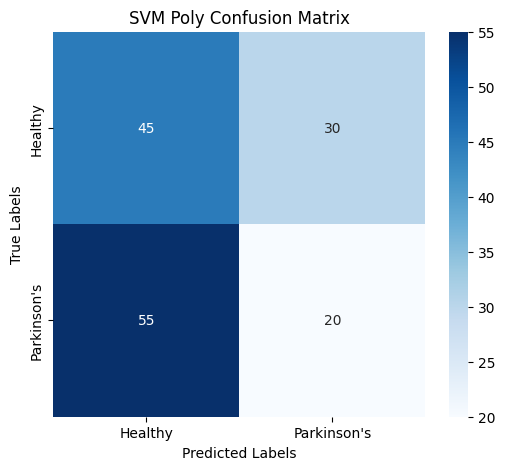

In [ ]:
clf = make_pipeline(StandardScaler(),SVC(kernel="poly", C=1, gamma = 'scale', degree= 3))
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
metrics = compute_metrics(cm)

# Display the metrics 
print(f"\nSVM Poly Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")
    print("")
    
# Display confusion matrix 
plt.figure(figsize=(6, 5))
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', xticklabels=["Healthy", "Parkinson's"], yticklabels=["Healthy", "Parkinson's"])
plt.title('SVM Poly Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()
#print("SVM:\n", classification_report(y_test, y_pred))

In [18]:
classifier_images = {}

idxs = np.arange(0, len(all_testing_filenames))
idxs = np.random.choice(idxs, size=(4,), replace=False)
images = []

clf = RandomForestClassifier(max_depth= None, max_features= None, min_samples_leaf= 4, min_samples_split= 2, n_estimators= 100)
clf.fit(X_train, y_train)

for i in idxs:
    image = cv.imread(all_testing_filenames[i])
    output = image.copy()
    
    y_pred = clf.predict(X_test[i])

    label = y_pred[0] #label_encoder.inverse_transform(preds)[0]

    # Annotate image
    color = (0, 255, 0) if label == "healthy" else (0, 0, 255)
    cv.putText(output, label, (3, 20), cv.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    # Store image
    classifier_images[clf].append(output)
	

# Show separate montages for each classifier 


for clf_name, images in classifier_images.items():
    # Create montage using 128x128 "tiles" with 5 rows and 5 columns
    montage = build_montages(images, (128, 128), (5, 5))[0]
    
    # Show montage
    cv.imshow(f"{clf_name} Output", montage)
    cv.waitKey(0)

KeyError: np.int64(7)

In [ ]:
# Store image
classifier_images[clf].append(output)
cm = confusion_matrix(y_test, y_pred)
metrics = compute_metrics(cm)

# Display the metrics 
print(f"\nSVM Poly Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")
    print("")
    
# Display montage 
plt.figure(figsize=(6, 5))
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', xticklabels=["Healthy", "Parkinson's"], yticklabels=["Healthy", "Parkinson's"])
plt.title('SVM Poly Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Similar to the GridSearch, the cell below also had some issues with processing. Code has been provided for clarity and an example of the outputs are contained in the other notebook. 

In [ ]:
import numpy as np
import cv2 as cv

In [16]:
# Visualize the work

# Initialize a dictionary to store images for each classifier
classifier_images = {}

# Randomly select a few images from testing set and then initialize 
# the output images for the montage
#testingPaths = list(paths.list_images(all_testing_filenames))
idxs = np.arange(0, len(all_testing_filenames))
idxs = np.random.choice(idxs, size=(4,), replace=False)
images = []

# Loop over testing samples
for i in idxs:
	# Load the testing image, clone it, and resize it
	image = cv.imread(all_testing_filenames[i])
	output = image.copy()
	#output = cv2.resize(output, (128, 128))
	
	# Pre-process the image like we did earlier
	preprocessed = preprocess_spiral_image(output)
	features = extract_features(preprocessed)
    
	
    # Add label information
	features['label_name'] = label_name
	testing_features_list = features

# Create DataFrame from all features
	testing_features_df = pd.DataFrame(testing_features_list)
X_test = testing_features_df[['circularity', 'corners', 'tremor_index']]
y_test = testing_features_df['label_name']

clf = RandomForestClassifier(max_depth=None, max_features=None, min_samples_leaf=4, min_samples_split=2, n_estimators=100)
	#clf = make_pipeline(RandomForestClassifier(kernel="poly", C=1, gamma = 'scale', degree= 3))
#'max_depth': None, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100
	#clf.fit(X_train, y_train)
	# Predictions for each classifier
	#for clf_name, clf in fitted_classifiers.items():
    # Convert feature dict to single-row DataFrame
	#	features_df = pd.DataFrame([features])
	#	features_df = features_df[clf.feature_names_in_]
    # Predict
preds = clf.predict(X_test)

    # Get label string (adjust depending on your encoder setup)
label = preds[0] #label_encoder.inverse_transform(preds)[0]

    # Annotate image
color = (0, 255, 0) if label == "healthy" else (0, 0, 255)
cv.putText(output, label, (3, 20), cv.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

# Store image
classifier_images[clf].append(output)
	

# Show separate montages for each classifier 


for clf_name, images in classifier_images.items():
    # Create montage using 128x128 "tiles" with 5 rows and 5 columns
    montage = build_montages(images, (128, 128), (5, 5))[0]
    
    # Show montage
    cv.imshow(f"{clf_name} Output", montage)
    cv.waitKey(0)
	

ValueError: If using all scalar values, you must pass an index